# Q-learning (on-policy) with value function approximation

# TODO:
- create a new notebook to describe new changes in the State class 

## setup frozen lake environment

In [1]:
from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)

In [2]:
# lake_grid =generate_grid_randomly(3, 3, 1)
lake_grid = [['F', 'F', 'F'],
             ['F', 'H', 'F'],
             ['F', 'F', 'G']]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

In [3]:
frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

## Q-learning algorithm with value function approximation

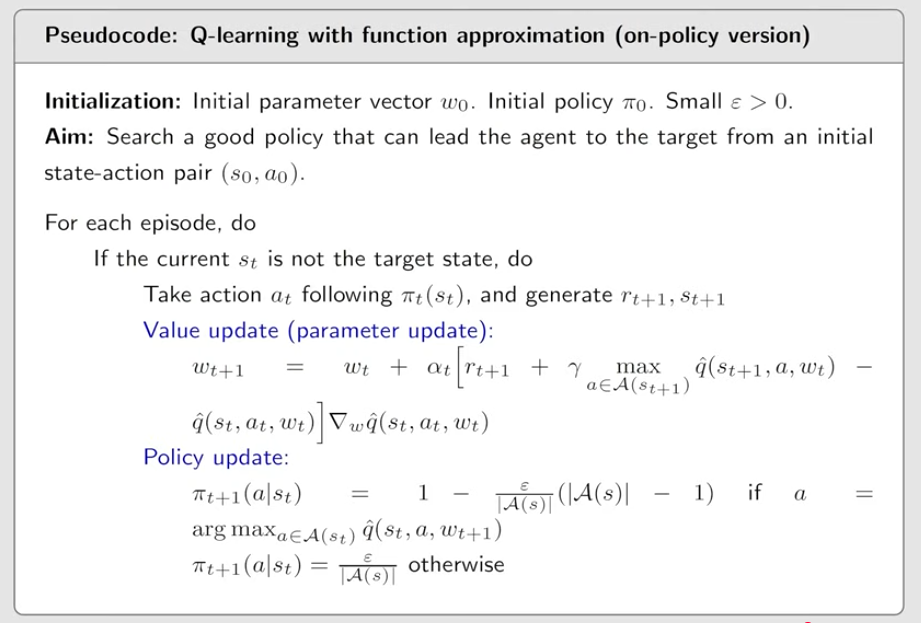

## TODO:
- add the derivative of this formula
  - W = alpha*(reward + gamma*next_max_q_s - q_s_a)*encoded_s_a

In [4]:
import random

In [5]:
def get_approx_Qsa(W, state, action, env):
    phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector

    Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
    return Q_s_a

def get_max_Q_s(W, state, env):
    Q_s = []
    for action in env.all_action_idx:
        phi_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
        Q_s_a = np.dot(phi_s_a, W) # action value of the given state-action pair
        Q_s.append(Q_s_a)
    return max(Q_s)

def get_Q_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    Q = np.zeros((env.n_states, env.n_actions), dtype=np.int16)
    for s in states:
        for a in env.all_action_idx:
            Q[s.idx][a] = get_approx_Qsa(W, s, a, env)
    return Q



In [6]:
def epsilon_greedy_policy(W, state, env, epsilon=0.2):
    actions = env.all_action_idx    
    if random.random() < epsilon:
        return random.choice(actions) # <---- exploration
    else:
        action_values = []
        for a in actions:
            Q_s_a = get_approx_Qsa(W, state, a, env)
            action_values.append(Q_s_a)
        return actions[np.argmax(action_values)] # <-- exploitation

In [7]:
def get_policy_table(W, env):
    states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
    policy = np.zeros(env.n_states, dtype=np.int16)
    for s in states:
        greedy_action = epsilon_greedy_policy(W, s, env, epsilon=0.0) # epsilon=0.0 -> greedy policy
        policy[s.idx] = greedy_action
    return policy

In [8]:
def run_episode(env, W, state, action, episode_idx, epsilon=0.2, alpha=0.1, gamma=0.1, verbose=0):
    step = 0
    trajectory = []
    while True:
        trajectory.append(state.coord)
        
        result = env.step(state, action)
        reward = result["reward"]

        next_state = result["new_state"]
        is_terminated = result["is_terminated"] # True if hole or goal ?

        next_action = epsilon_greedy_policy(W,
                                            next_state,
                                            env,
                                            epsilon=1.0) # epsilon = 1 -> off-policy

        # --- update W ---------------------
        # ----------------------------------
        encoded_s_a = state.get_one_hot_encoding(action,
                                         env.n_states,
                                         env.n_actions) # state-action feature vector
        
        next_max_q_s = get_max_Q_s(W,
                              next_state,
                              env)
        
        q_s_a = get_approx_Qsa(W,
                      state,
                      action,
                      env)
        
        W += alpha * (reward + gamma*next_max_q_s - q_s_a)*encoded_s_a
        # ----------------------------------
        # ----------------------------------

        prev_state = state
        state = next_state
        action = next_action
        
        if verbose == 1:
            print(f"step {step}: state: {prev_state.coord} -> Action: {action} -> Reward: {reward} -> Next state: {state.coord}")
        elif verbose == 2:
            policy = get_policy_table(W, env)
            env.render(policy, next_state, episode_idx, step, reward)
            
        if is_terminated:
            break
        step += 1
    trajectory.append(state.coord)
    return W, get_policy_table(W, env), trajectory

In [9]:
def run_q_learning_with_fa(env, n_episodes=500, epsilon=0.2, alpha=0.2, gamma=0.2, verbose=0):
    policy_history = []
    W_history = []

    n_features = env.n_states * env.n_actions
    W = np.zeros(n_features)

    trajectory_history = []
    for episode_idx in range(n_episodes):
        initial_state = env.find('S')
        initial_action = 2 #randomly picked

        W, greedy_policy, trajectory = run_episode(env,
                                                    W, 
                                                   initial_state, 
                                                   initial_action, 
                                                   episode_idx,
                                                   epsilon=epsilon,
                                                   alpha=alpha,
                                                   gamma=gamma,
                                                   verbose=verbose)
        trajectory_history.append(trajectory)
        policy_history.append(greedy_policy)
        W_history.append(W)
    return W, policy_history, W_history, trajectory_history

In [10]:
lake_grid = [["F", "F", "S", "F"],
             ["F", "F", "H", "F"],
             ["F", "F", "F", "G"],
             ["F", "H", "F", "F"]]
# lake_grid = [["F", "F", "S", "F", "H"],
#              ["F", "F", "H", "F", "F"],
#              ["F", "F", "F", "G", "F"],
#              ["F", "H", "F", "F", "F"],
#              ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [11]:
W, policy_history, W_history, trajectory_history = run_q_learning_with_fa(frozen_lake,
                                                      n_episodes=500,
                                                      epsilon=0.2,
                                                      verbose=0)

In [12]:
policy = policy_history[-1] 

In [13]:
policy

array([2, 2, 2, 1, 2, 1, 0, 1, 0, 2, 2, 0, 3, 0, 3, 0], dtype=int16)

In [14]:
W

array([7.39670880e-04, 6.98769124e-04, 3.72494654e-03, 1.59298735e-03,
       6.57119325e-03, 1.16992230e-02, 2.93644685e-02, 5.96932089e-03,
       1.05728505e-01, 3.75001850e-03, 2.27807712e-01, 3.23688189e-02,
       1.46214184e-01, 1.14598535e+00, 2.73413266e-01, 3.95589563e-01,
       2.07884775e-03, 2.98524284e-03, 3.33044528e-03, 1.33496990e-03,
       4.41728007e-03, 5.51232889e-02, 2.05793683e-02, 1.40149889e-02,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       6.94856336e-01, 8.20574608e+00, 2.97730111e+00, 2.06703484e+00,
       1.70846641e-02, 1.62379681e-03, 1.37195903e-02, 1.03960253e-03,
       7.64732384e-02, 8.77452193e-03, 3.75152697e-01, 2.20901632e-02,
       1.60724704e+00, 5.24800000e-03, 4.88000000e+00, 3.60000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       4.47169090e-04, 1.09955056e-04, 0.00000000e+00, 7.50925166e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [15]:
Q = get_Q_table(W, frozen_lake)
Q

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 8, 2, 2],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [1, 0, 4, 3],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [3, 0, 0, 0]], dtype=int16)

In [16]:
def convert_1d_to_2d_policy(policy_1d, n_rows, n_cols):
    policy_2d = np.zeros((n_rows, n_cols),dtype=np.int16)

    for idx, value in enumerate(policy_1d):
        r, c = State(idx, n_cols).coord
        policy_2d[r][c] = value
    return policy_2d

In [17]:
policy_2d = convert_1d_to_2d_policy(policy, frozen_lake.n_rows, frozen_lake.n_cols)
policy_2d

array([[2, 2, 2, 1],
       [2, 1, 0, 1],
       [0, 2, 2, 0],
       [3, 0, 3, 0]], dtype=int16)

# Render policy

In [18]:
import pandas as pd
from IPython.display import display

In [19]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,→,→,🚀 →,↓
1,→,↓,🕳️,↓
2,←,→,→,🏁
3,↑,🕳️,↑,←


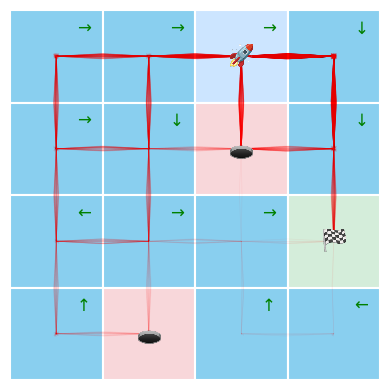

In [20]:
plot_trajectory_history(frozen_lake,trajectory_history, policy)

## Animate Policy history

In [21]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [22]:
ani = animate_policy_value_video(frozen_lake, policy_history[-10:])
HTML(ani.to_jshtml())

# Play with different grid setup

In [23]:
grid = generate_grid_randomly(4, 4, n_holes=4)
grid

[['F', 'H', 'F', 'F'],
 ['F', 'H', 'S', 'F'],
 ['F', 'F', 'H', 'F'],
 ['F', 'G', 'H', 'F']]

In [24]:
frozen_lake = FrozenLakeEnvironment(grid=grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [25]:
Q, policy_history, Q_history, traj_history = run_q_learning_with_fa(frozen_lake, n_episodes=5000, verbose=0)

In [26]:
policy = policy_history[-1]

In [27]:
render_policy_and_value(frozen_lake, policy, None)

Policy:


,0,1,2,3
0,←,🕳️,←,←
1,←,🕳️,🚀 ←,←
2,←,←,🕳️,←
3,←,🏁,🕳️,←


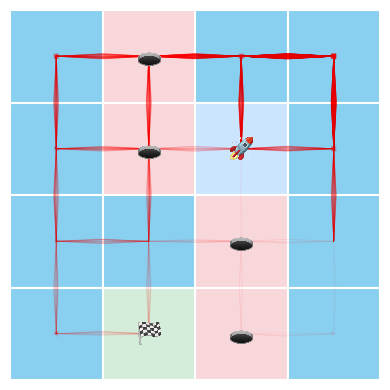

In [28]:
plot_trajectory_history(frozen_lake,trajectory_history, policy=None)